In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [12]:
def parse_improvement_file(filename):
    """Parse improvement file and return (times, objectives) arrays."""
    times = []
    objectives = []
    
    try:
        with open(filename, 'r') as f:
            for line in f:
                line = line.strip()
                # Skip comments and empty lines
                if not line or line.startswith('#'):
                    continue
                
                parts = line.split()
                if len(parts) >= 2:
                    try:
                        time = float(parts[0])
                        obj = float(parts[1])
                        times.append(time)
                        objectives.append(obj)
                    except ValueError:
                        continue
    except FileNotFoundError:
        print(f"Warning: File {filename} not found, skipping...")
        return None, None
    except Exception as e:
        print(f"Error reading {filename}: {e}")
        return None, None
    
    if len(times) == 0:
        print(f"Warning: No data found in {filename}")
        return None, None
    
    return np.array(times), np.array(objectives)

In [29]:
def plot_subgraph(instance_name, base_obj, ax, yscale_limit=2., xscale_limit=900):
    pdbo_file = f"./results/pdbo_xlogx/{instance_name}.txt"
    rots_file = f"./results/baseline/{instance_name}_rots_improvements.txt"
    bma_file = f"./results/baseline/{instance_name}_bma_improvements.txt"

    pdbo_time, pdbo_obj = parse_improvement_file(pdbo_file)
    rots_time, rots_obj = parse_improvement_file(rots_file)
    bma_time, bma_obj = parse_improvement_file(bma_file)
    
    pdbo_mask = pdbo_time <= xscale_limit
    rots_mask = rots_time <= xscale_limit
    bma_mask = bma_time <= xscale_limit

    pdbo_obj = pdbo_obj[pdbo_mask]
    rots_obj = rots_obj[rots_mask]
    bma_obj = bma_obj[bma_mask]

    # base_obj = min(bma_obj)

    pdbo_obj = np.minimum((pdbo_obj - base_obj) / base_obj, yscale_limit)
    rots_obj = np.minimum((rots_obj - base_obj) / base_obj, yscale_limit)
    bma_obj = np.minimum((bma_obj - base_obj) / base_obj, yscale_limit)
    print(min(pdbo_obj), min(rots_obj), min(bma_obj))

    pdbo_time = pdbo_time[pdbo_mask]
    rots_time = rots_time[rots_mask]
    bma_time = bma_time[bma_mask]
    
    
    colors = ["#d8904c", "#60a3c9", "#6cb0a1"]
    # linestyles = ['-', '--', '-.', ':']

    ax.plot(pdbo_time, pdbo_obj, label="SRPD", 
                color=colors[0], linewidth=2, marker='o', 
                markersize=3, markevery=max(1, len(pdbo_time)//50))

    ax.plot(rots_time, rots_obj, label="Ro-TS", 
                color=colors[1], linewidth=2, marker='o', 
                markersize=3, markevery=max(1, len(rots_time)//50))

    ax.plot(bma_time, bma_obj, label="BMA", 
                color=colors[2], linewidth=2, marker='o', 
                markersize=3, markevery=max(1, len(bma_time)//50))
    ax.set_xlabel('Time (s)', fontsize=12)
    
    # set y-tick to be percentages
    yticks = np.arange(0, yscale_limit+0.1, 0.25)
    yticklabels = [f"{int(y*100)}%" for y in yticks]
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels, fontsize=10)
    # ax.set_ylim(0.9, yscale_limit+0.1)
    ax.set_ylim(-0.1, yscale_limit+0.1)
    ax.set_xlim(-20, xscale_limit)
    # ax.set_ylabel('Normalized Objective', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.set_title(f'{instance_name}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

In [30]:
n = 125
xscale_limit = 900
yscale_limit = 1.5

bks = pd.read_csv('taillarde_labels.txt', sep=' ', header=None, index_col=0, names=['instance', 'label'])

0.029977982272906906 0.12194433466945181 0.07644103201038785
0.05390016031842556 0.08778815854939466 0.02869146995411576
0.056134828513345135 0.15214112400813168 0.10964653419896386
0.03748035304074477 0.4045460041107484 0.05857816467174465
0.017414673474872345 0.07616232195646332 0.04713786616500941


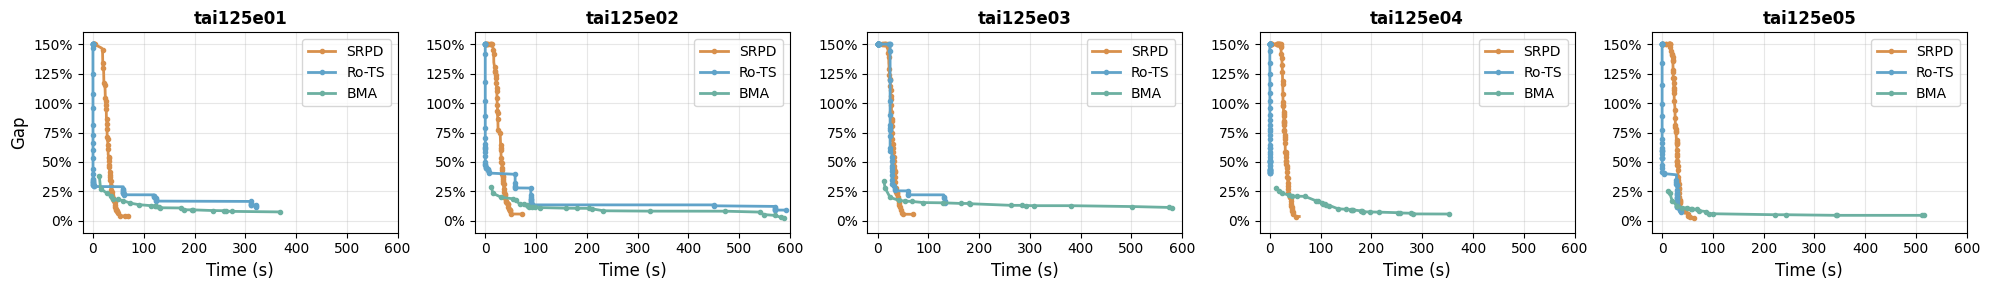

0.09899200556134863 0.13694820994091067 0.08738269030239833
0.056795050888046296 0.31993614049091995 0.15589702654160847
0.03473098330241187 1.5 0.14115027829313542
0.11228813559322035 1.5 0.052701271186440676
0.09791216702663787 0.24270058395328373 0.14034877209823216


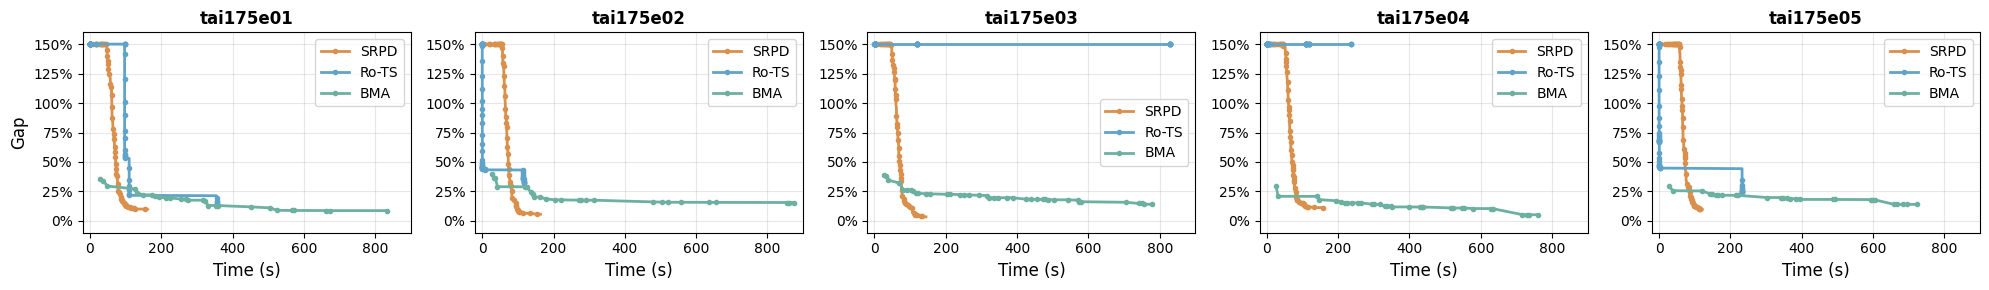

0.05418013725823833 0.2565084226646248 0.1902047529918893
0.030312819684488235 0.235624293329026 0.1828595272707694
0.026194296652872786 0.2448554457675309 0.1715508262252625
0.04900435390871174 1.3649569185309154 0.16461174378620086
0.05149733312247509 1.5 0.18098825423753181


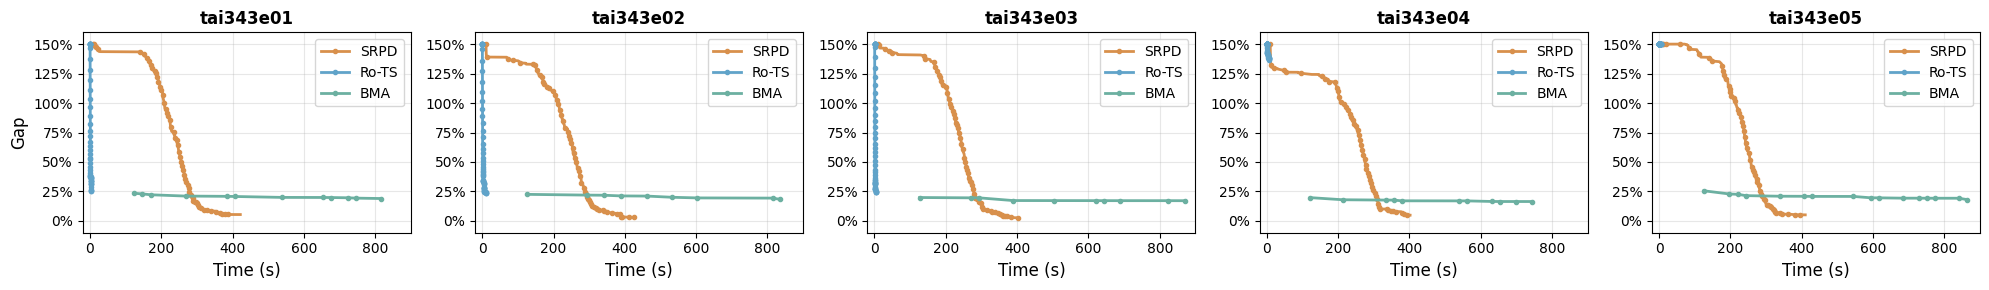

0.07040311343871619 1.1220150867246432 0.1991687887378081
0.06577845090754195 1.1626476086802187 0.1964881558085051
0.04315512933205598 0.22904958963368263 0.19356352036029273
0.0587779419243903 1.1894650165895715 0.18987672858492166
0.06063853709648867 1.1699639728432747 0.21976565602438172


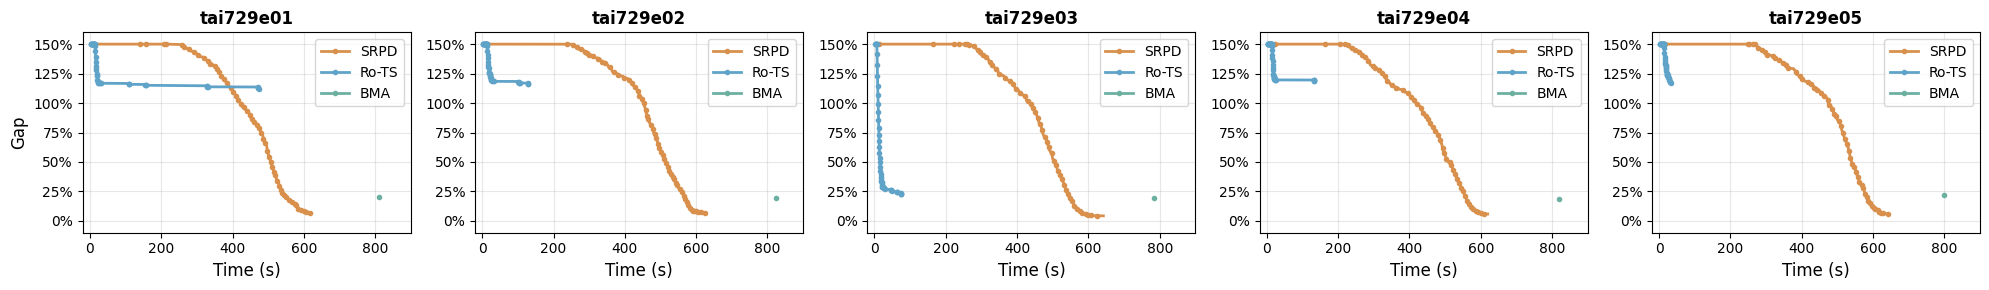

In [31]:
for n in [125, 175, 343, 729]:
    fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 3))

    for i, ax in enumerate(axes):
        instance_name = f"tai{n}e0{i+1}"
        if n == 125:
            xscale_limit = 600
        else:
            xscale_limit = 900
        plot_subgraph(instance_name, bks.loc[instance_name].values, ax, yscale_limit=yscale_limit, xscale_limit=xscale_limit)
        if i == 0 :
            ax.set_ylabel('Gap', fontsize=12)
            

    plt.tight_layout()
    plt.savefig(f'comparison_tai{n}e.pdf', dpi=800, bbox_inches='tight')
    plt.show()

0.029977982272906906 0.16829447298594252 0.08112685598148253
0.09899200556134863 0.13694820994091067 0.08738269030239833
0.05418013725823833 0.2565084226646248 0.1902047529918893
0.07040311343871619 1.1220150867246432 0.1991687887378081
0.05390016031842556 0.13627066172812205 0.0861849742937697
0.056795050888046296 0.31993614049091995 0.15589702654160847
0.030312819684488235 0.235624293329026 0.1828595272707694
0.06577845090754195 1.1626476086802187 0.1964881558085051
0.056134828513345135 0.15214112400813168 0.13089382910354777
0.03473098330241187 1.5 0.14115027829313542
0.026194296652872786 0.2448554457675309 0.1715508262252625
0.04315512933205598 0.22904958963368263 0.19356352036029273
0.03748035304074477 0.4045460041107484 0.05954539958892516
0.11228813559322035 1.5 0.052701271186440676
0.04900435390871174 1.3649569185309154 0.16461174378620086
0.0587779419243903 1.1894650165895715 0.18987672858492166
0.017414673474872345 0.07616232195646332 0.05262026337006181
0.09791216702663787 0

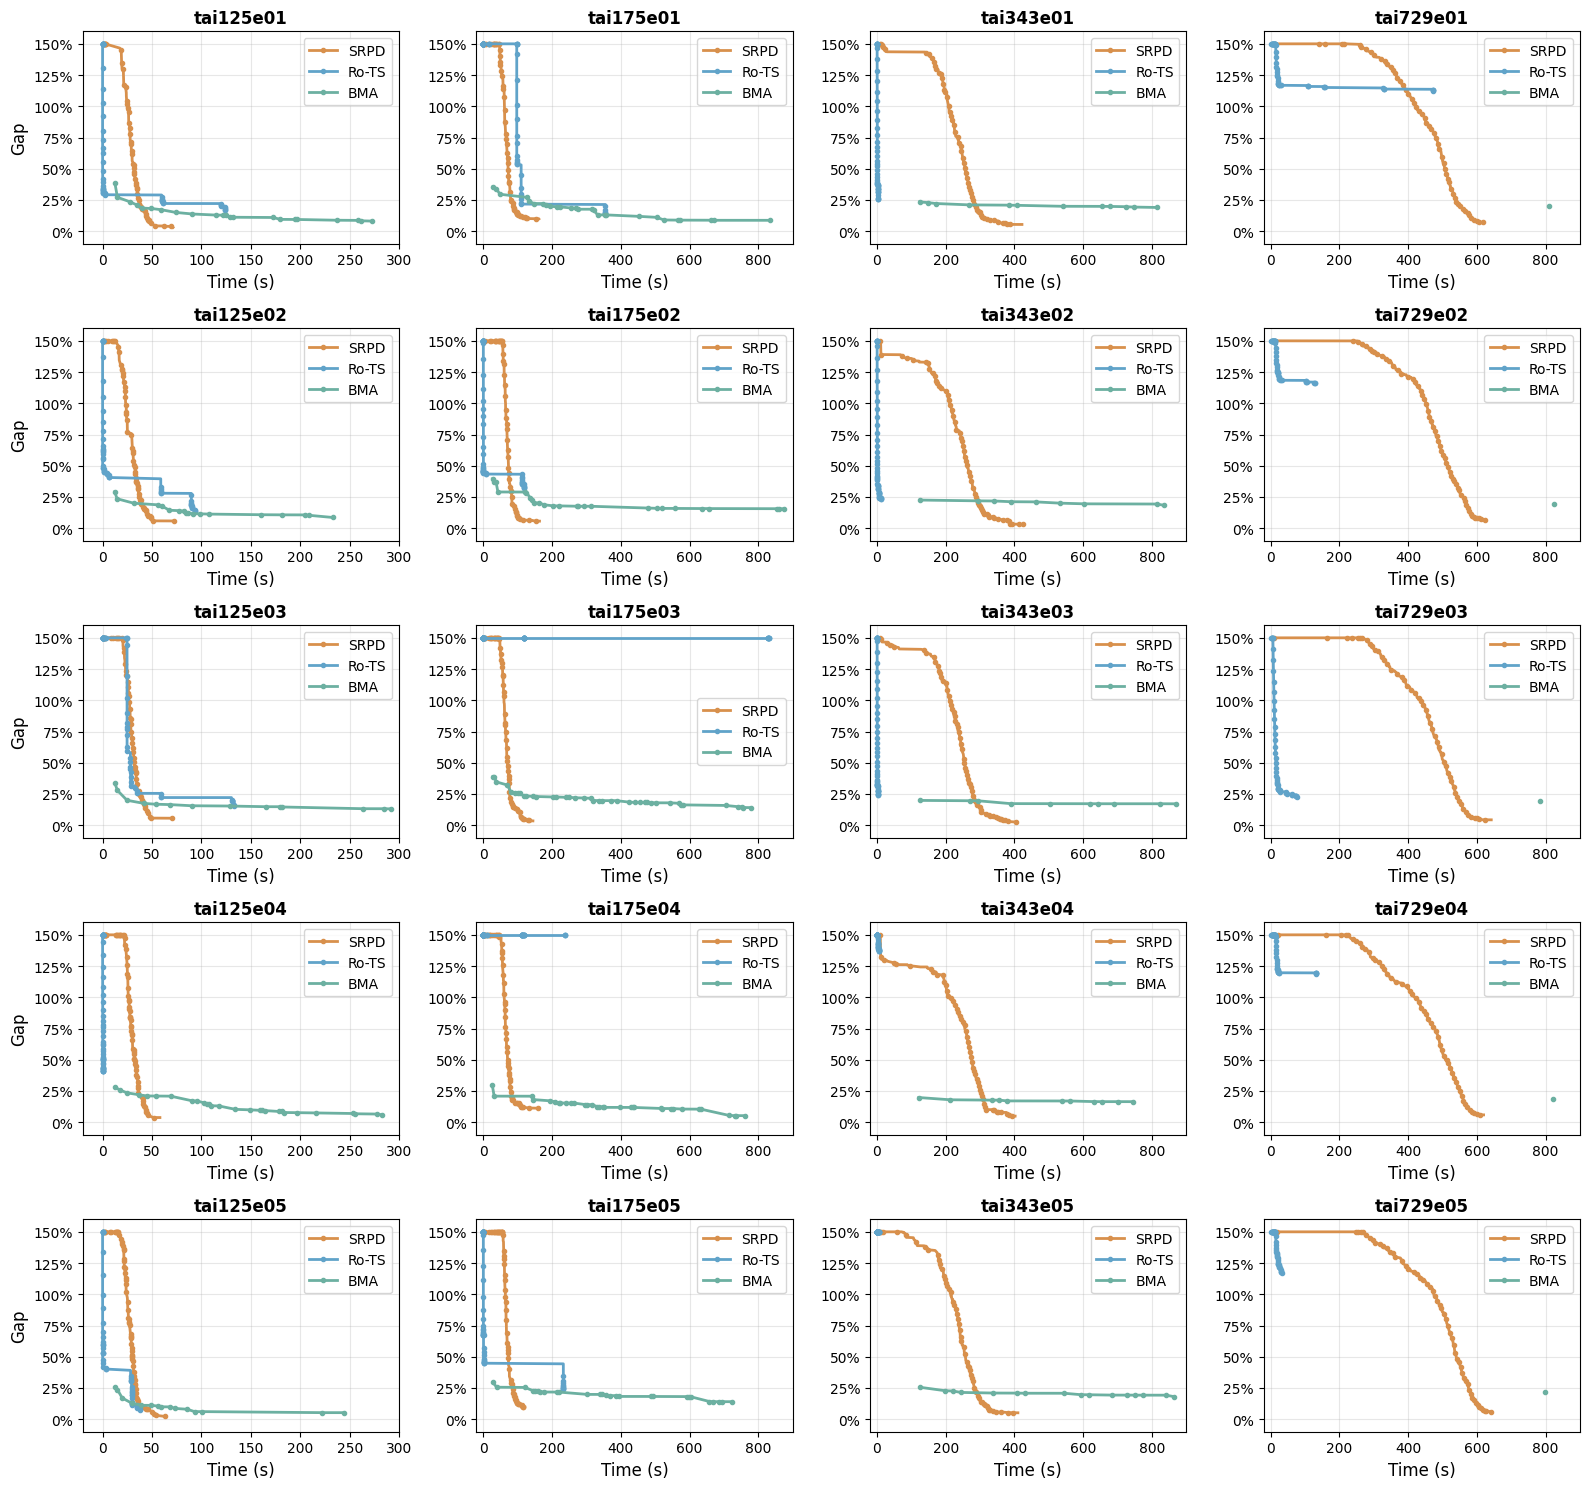

In [32]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(16, 15))

for i in range(5):
    for j in range(4):
        n = [125, 175, 343, 729][j]
        ax = axes[i, j]
        instance_name = f"tai{n}e0{i+1}"
        if n == 125:
            xscale_limit = 300
        else:
            xscale_limit = 900
        plot_subgraph(instance_name, bks.loc[instance_name].values, ax, yscale_limit=yscale_limit, xscale_limit=xscale_limit)
        if j == 0 :
            ax.set_ylabel('Gap', fontsize=12)
# for n in [125, 175, 343, 729]:
    

#     for i, ax in enumerate(axes):
#         instance_name = f"tai{n}e0{i+1}"
#         plot_subgraph(instance_name, bks.loc[instance_name].values, ax, yscale_limit=yscale_limit, xscale_limit=xscale_limit)
#         if i == 0 :
#             ax.set_ylabel('Gap', fontsize=12)
            

plt.tight_layout()
plt.savefig(f'comparison.pdf', dpi=800, bbox_inches='tight')
plt.show()

0.029977982272906906 0.16829447298594252 0.08112685598148253
0.09899200556134863 0.13694820994091067 0.08738269030239833
0.05418013725823833 0.2565084226646248 0.1902047529918893
0.07040311343871619 1.1220150867246432 0.1991687887378081
0.05390016031842556 0.13627066172812205 0.0861849742937697
0.056795050888046296 0.31993614049091995 0.15589702654160847
0.030312819684488235 0.235624293329026 0.1828595272707694
0.06577845090754195 1.1626476086802187 0.1964881558085051
0.056134828513345135 0.15214112400813168 0.13089382910354777
0.03473098330241187 1.5 0.14115027829313542
0.026194296652872786 0.2448554457675309 0.1715508262252625
0.04315512933205598 0.22904958963368263 0.19356352036029273


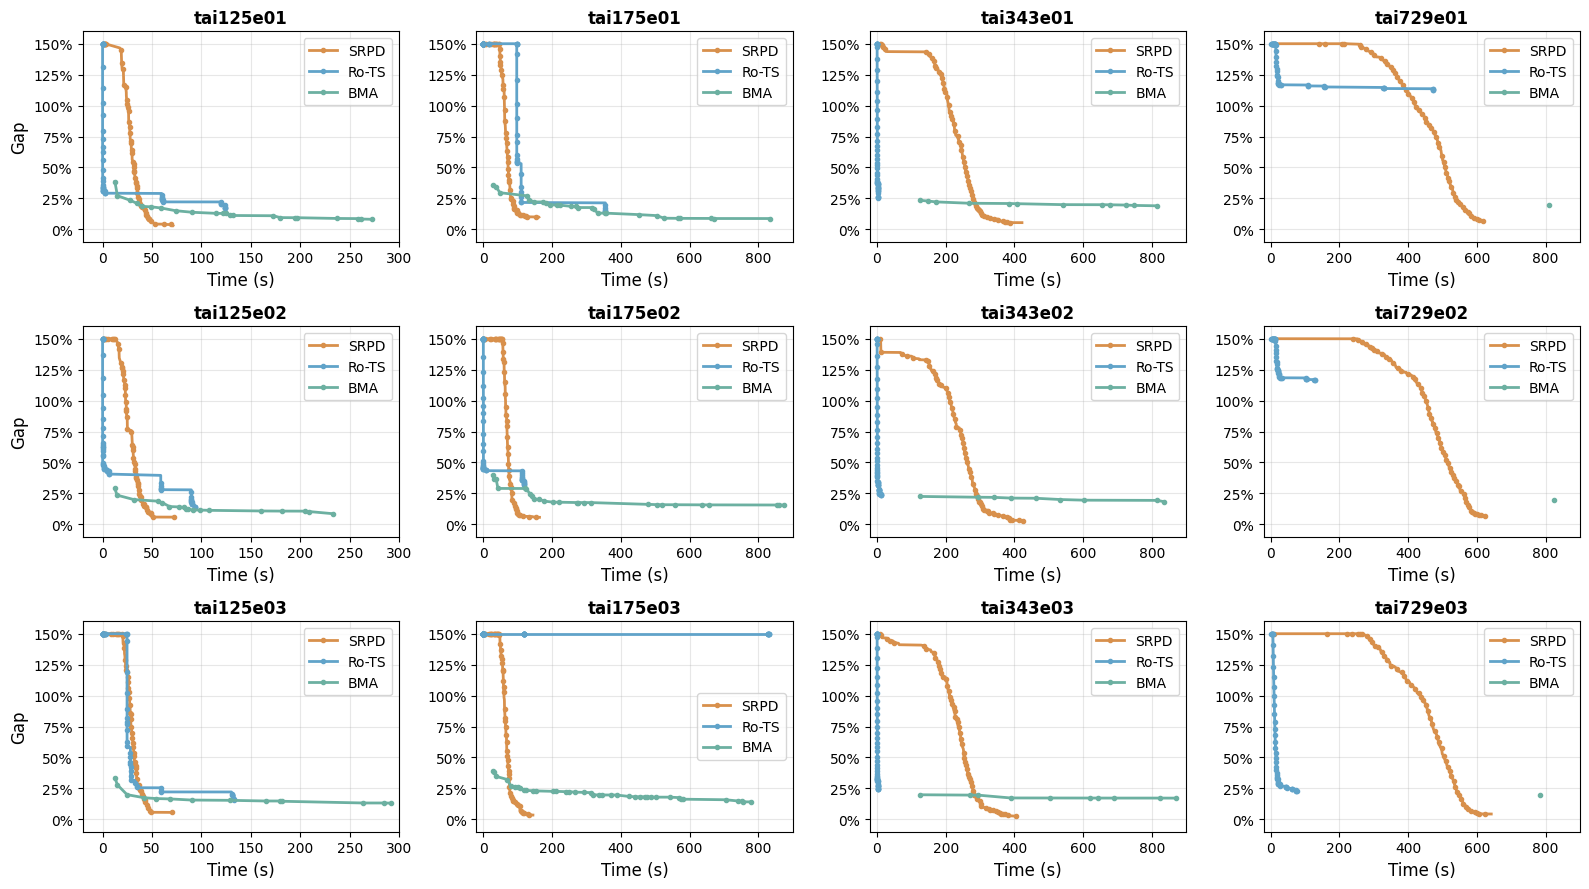

In [33]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 9))

for i in range(3):
    for j in range(4):
        n = [125, 175, 343, 729][j]
        ax = axes[i, j]
        instance_name = f"tai{n}e0{i+1}"
        if n == 125:
            xscale_limit = 300
        else:
            xscale_limit = 900
        plot_subgraph(instance_name, bks.loc[instance_name].values, ax, yscale_limit=yscale_limit, xscale_limit=xscale_limit)
        if j == 0 :
            ax.set_ylabel('Gap', fontsize=12)
# for n in [125, 175, 343, 729]:
    

#     for i, ax in enumerate(axes):
#         instance_name = f"tai{n}e0{i+1}"
#         plot_subgraph(instance_name, bks.loc[instance_name].values, ax, yscale_limit=yscale_limit, xscale_limit=xscale_limit)
#         if i == 0 :
#             ax.set_ylabel('Gap', fontsize=12)
            

plt.tight_layout()
plt.savefig(f'comparison2.pdf', dpi=800, bbox_inches='tight')
plt.show()

In [34]:
instance_name = "tai175e05"

pdbo_file = f"./results/pdbo/{instance_name}.txt"
rots_file = f"./results/baseline/{instance_name}_rots_improvements.txt"
bma_file = f"./results/baseline/{instance_name}_bma_improvements.txt"


pdbo_time, pdbo_obj = parse_improvement_file(pdbo_file)
rots_time, rots_obj = parse_improvement_file(rots_file)
bma_time, bma_obj = parse_improvement_file(bma_file)

In [35]:
yscale_limit = 2.5
xscale_limit = 900

pdbo_mask = pdbo_time <= xscale_limit
rots_mask = rots_time <= xscale_limit
bma_mask = bma_time <= xscale_limit

pdbo_obj = pdbo_obj[pdbo_mask]
rots_obj = rots_obj[rots_mask]
bma_obj = bma_obj[bma_mask]

base_obj = min(bma_obj)

pdbo_obj = np.minimum(pdbo_obj / base_obj, yscale_limit)
rots_obj = np.minimum(rots_obj / base_obj, yscale_limit)
bma_obj = np.minimum(bma_obj / base_obj, yscale_limit)

pdbo_time = pdbo_time[pdbo_mask]
rots_time = rots_time[rots_mask]
bma_time = bma_time[bma_mask]

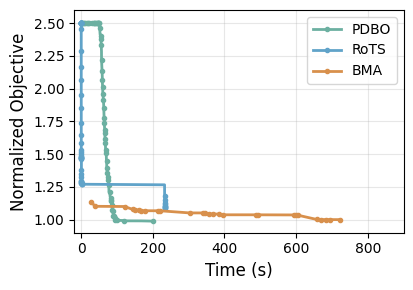

In [36]:
plt.figure(figsize=(4, 3))
colors = ["#6cb0a1", "#60a3c9", "#d8904c"]
# linestyles = ['-', '--', '-.', ':']

plt.plot(pdbo_time, pdbo_obj, label="PDBO", 
            color=colors[0], linewidth=2, marker='o', 
            markersize=3, markevery=max(1, len(pdbo_time)//50))

plt.plot(rots_time, rots_obj, label="RoTS", 
            color=colors[1], linewidth=2, marker='o', 
            markersize=3, markevery=max(1, len(rots_time)//50))

plt.plot(bma_time, bma_obj, label="BMA", 
            color=colors[2], linewidth=2, marker='o', 
            markersize=3, markevery=max(1, len(bma_time)//50))
plt.xlabel('Time (s)', fontsize=12)
plt.tight_layout()
plt.ylim(0.9, 2.6)
plt.xlim(-20, 900)
plt.ylabel('Normalized Objective', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# result table

In [21]:
import pandas as pd

In [22]:
instance_list = [f"tai{xx}e{yy:02d}" for xx in [125, 175, 343, 729] for yy in range(1,4)]
instance_list

['tai125e01',
 'tai125e02',
 'tai125e03',
 'tai175e01',
 'tai175e02',
 'tai175e03',
 'tai343e01',
 'tai343e02',
 'tai343e03',
 'tai729e01',
 'tai729e02',
 'tai729e03']

In [23]:
df = pd.read_csv('taillarde_labels.txt', sep=' ', header=None, index_col=0, names=['instance', 'label'])
df = df.loc[instance_list]
df

,label
instance,
tai125e01,35426
tai125e02,36178
tai125e03,30498
tai175e01,57540
tai175e02,50110
tai175e03,53900
tai343e01,141048
tai343e02,148584
tai343e03,142092


In [29]:
xx_list = [125, 175, 343, 729]

# read the lables
obj_list = []
time_list = []  
for xx in xx_list:
    for yy in range(1,4):
        instance_name = f"tai{xx}e0{yy}"
        
        # pdbo_file = f"./results/pdbo_xlogx/{instance_name}.txt"
        rots_file = f"./results/baseline/{instance_name}_rots_improvements.txt"
        # bma_file = f"./results/baseline/{instance_name}_bma_improvements.txt"
        # pdbo_time, pdbo_obj = parse_improvement_file(pdbo_file)
        rots_time, rots_obj = parse_improvement_file(rots_file)
        # bma_time, bma_obj = parse_improvement_file(bma_file)
        obj_list.append(int(rots_obj[-2]))
        time_list.append(int(rots_time[-2]))
df['rots_obj'] = obj_list
df['rots_time'] = time_list


obj_list = []
time_list = []  
for xx in xx_list:
    for yy in range(1,4):
        instance_name = f"tai{xx}e0{yy}"
        
        bma_file = f"./results/baseline/{instance_name}_bma_improvements.txt"
        bma_time, bma_obj = parse_improvement_file(bma_file)
        obj_list.append(int(bma_obj[-2]))
        time_list.append(int(bma_time[-2]))
df['bma_obj'] = obj_list
df['bma_time'] = time_list

obj_list = []
time_list = []  
for xx in xx_list:
    for yy in range(1,4):
        instance_name = f"tai{xx}e0{yy}"
        
        pdbo_file = f"./results/pdbo_xlogx/{instance_name}.txt"
        pdbo_time, pdbo_obj = parse_improvement_file(pdbo_file)
        obj_list.append(int(pdbo_obj[-2]))
        time_list.append(int(pdbo_time[-2]))
df['pdbo_obj'] = obj_list
df['pdbo_time'] = time_list

# add ,to separate thousands
df['label'] = df['label'].apply(lambda x: f"{x:,}")
df['rots_obj'] = df['rots_obj'].apply(lambda x: f"{x:,}")
df['rots_time'] = df['rots_time'].apply(lambda x: f"{x:,}")
df['bma_obj'] = df['bma_obj'].apply(lambda x: f"{x:,}")
df['bma_time'] = df['bma_time'].apply(lambda x: f"{x:,}")
df['pdbo_obj'] = df['pdbo_obj'].apply(lambda x: f"{x:,}")
df['pdbo_time'] = df['pdbo_time'].apply(lambda x: f"{x:,}")

df.to_latex('improvement_table.tex', index=True)


# nug12

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

/tmp/ipykernel_2828979/660691576.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


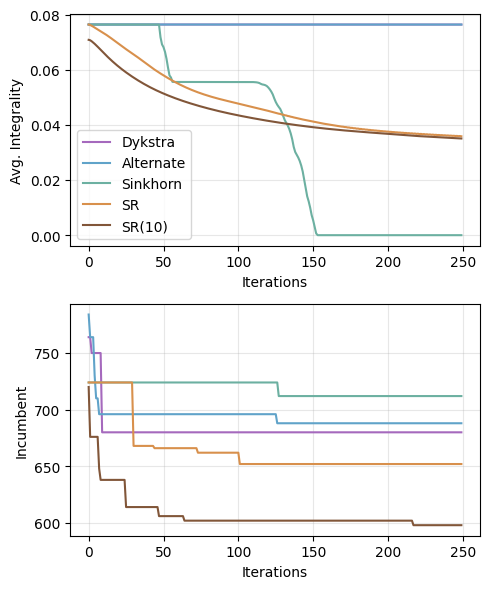

In [12]:
df = pd.read_csv('/home/xjx/A-xjx/QAPs/results/nug12_results.csv')
df = df.iloc[:250, :]
colors = ["#d8904c", "#60a3c9", "#6cb0a1"]
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 3), constrained_layout=True)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(5, 6), constrained_layout=True)
ax = axes[0]
ax.plot(df['Dykstra'] / 144, label='Dykstra', color='#a569bd')
ax.plot(df['Alter']/144, label='Alternate', color=colors[1])
ax.plot(df['Sinkhorn']/144, label='Sinkhorn', color=colors[2])
ax.plot(df['SR'], label='SR', color=colors[0])
ax.plot(df['SR(10)'], label='SR(10)', color="#815639")
ax.set_xlabel('Iterations', fontsize=10)
ax.set_ylabel('Avg. Integrality', fontsize=10)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)


df = pd.read_csv('/home/xjx/A-xjx/QAPs/results/nug12_obj.csv')
df = df.iloc[:250, :]
colors = ["#d8904c", "#60a3c9", "#6cb0a1"]
ax = axes[1]
ax.plot(df['Dykstra'], label='Dykstra', color='#a569bd')
ax.plot(df['Alter'], label='Alternate', color=colors[1])
ax.plot(df['Sinkhorn'], label='Sinkhorn', color=colors[2])
ax.plot(df['SR'], label='SR', color=colors[0])
ax.plot(df['SR(10)'], label='SR(10)', color="#815639")
ax.set_xlabel('Iterations', fontsize=10)
# set the y-tick to the right side
# ax.yaxis.set_label_position("right")
# ax.yaxis.tick_right()
ax.set_ylabel('Incumbent', fontsize=10)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nug12_convergence.pdf', dpi=800, bbox_inches='tight')
plt.show()
# plt.show()

In [8]:
df = pd.read_csv('/home/xjx/A-xjx/QAPs/results/nug12_results.csv')
# df = df.iloc[:200, :]
df

,Step,Dykastra,PGD,SR,Sinkhorn
0,0,11.000000,11.000000,11.000000,1.100000e+01
1,1,11.000000,11.000000,10.976012,1.100000e+01
2,2,11.000000,11.000000,10.935597,1.100000e+01
3,3,11.000000,11.000000,10.889774,1.100000e+01
4,4,11.000000,11.000000,10.841412,1.100000e+01
...,...,...,...,...,...
495,495,9.844018,9.848517,4.958933,2.810000e-14
496,496,9.834771,9.839116,4.948515,2.810000e-14
497,497,9.826077,9.830571,4.957321,2.810000e-14
498,498,9.817163,9.821793,4.947034,2.810000e-14


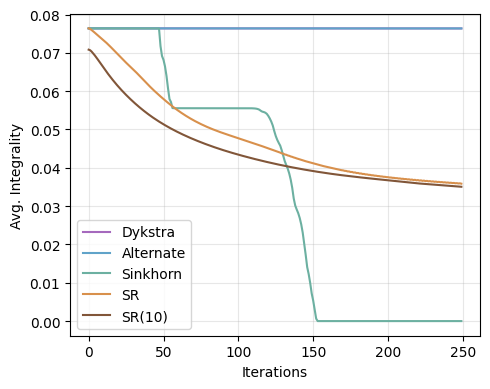

In [8]:
df = pd.read_csv('/home/xjx/A-xjx/QAPs/results/nug12_results.csv')
df = df.iloc[:250, :]
colors = ["#d8904c", "#60a3c9", "#6cb0a1"]
plt.figure(figsize=(5, 4))
ax = plt.gca()
ax.plot(df['Dykstra'] / 144, label='Dykstra', color='#a569bd')
ax.plot(df['Alter']/144, label='Alternate', color=colors[1])
ax.plot(df['Sinkhorn']/144, label='Sinkhorn', color=colors[2])
ax.plot(df['SR'], label='SR', color=colors[0])
ax.plot(df['SR(10)'], label='SR(10)', color="#815639")
ax.set_xlabel('Iterations', fontsize=10)
ax.set_ylabel('Avg. Integrality', fontsize=10)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nug12_integrality.pdf', dpi=800, bbox_inches='tight')
plt.show()

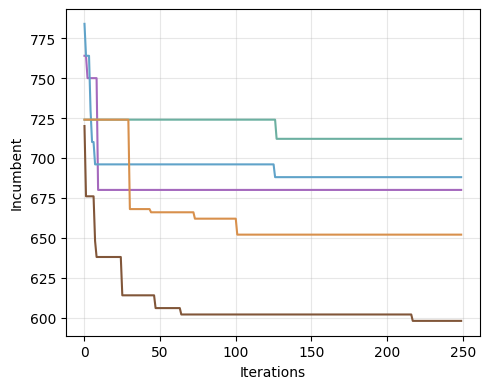

In [9]:
df = pd.read_csv('/home/xjx/A-xjx/QAPs/results/nug12_obj.csv')
df = df.iloc[:250, :]
colors = ["#d8904c", "#60a3c9", "#6cb0a1"]
plt.figure(figsize=(5, 4))
ax = plt.gca()
ax.plot(df['Dykstra'], label='Dykstra', color='#a569bd')
ax.plot(df['Alter'], label='Alternate', color=colors[1])
ax.plot(df['Sinkhorn'], label='Sinkhorn', color=colors[2])
ax.plot(df['SR'], label='SR', color=colors[0])
ax.plot(df['SR(10)'], label='SR(10)', color="#815639")
ax.set_xlabel('Iterations', fontsize=10)
# set the y-tick to the right side
# ax.yaxis.set_label_position("right")
# ax.yaxis.tick_right()
ax.set_ylabel('Incumbent', fontsize=10)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nug12_incumbent.pdf', dpi=800, bbox_inches='tight')
plt.show()